## Task 1

In [1]:
import seaborn as sns

df = sns.load_dataset("penguins")

In [2]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [4]:
df_cleaned = df.dropna().reset_index(drop=True)

In [5]:
df_cleaned.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [6]:
df.shape

(344, 7)

In [7]:
df_cleaned.shape

(333, 7)

In [8]:
print("--- Summary Statistics (Numerical Features) ---")
print(df_cleaned.describe())

print("\n--- Categorical Distributions ---")
print(df_cleaned['species'].value_counts())
print(df_cleaned['island'].value_counts())
print(df_cleaned['sex'].value_counts())

--- Summary Statistics (Numerical Features) ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000

--- Categorical Distributions ---
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
sex
Male      168
Female    165
Name: count, dtype: int64


In [9]:
# Outlier Detection
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
print("Outlier Detection (IQR Method)")
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers")

Outlier Detection (IQR Method)
bill_length_mm: Found 0 outliers
bill_depth_mm: Found 0 outliers
flipper_length_mm: Found 0 outliers
body_mass_g: Found 0 outliers


In [10]:
import matplotlib.pyplot as plt

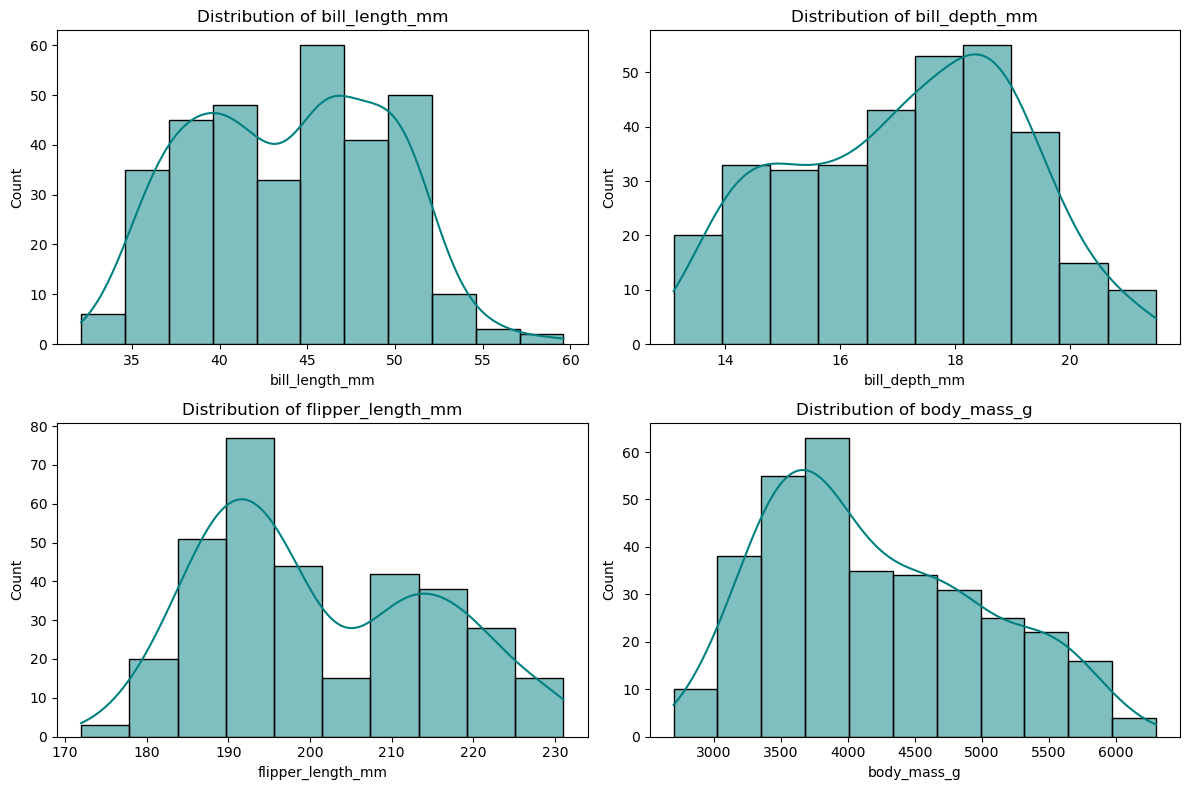

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

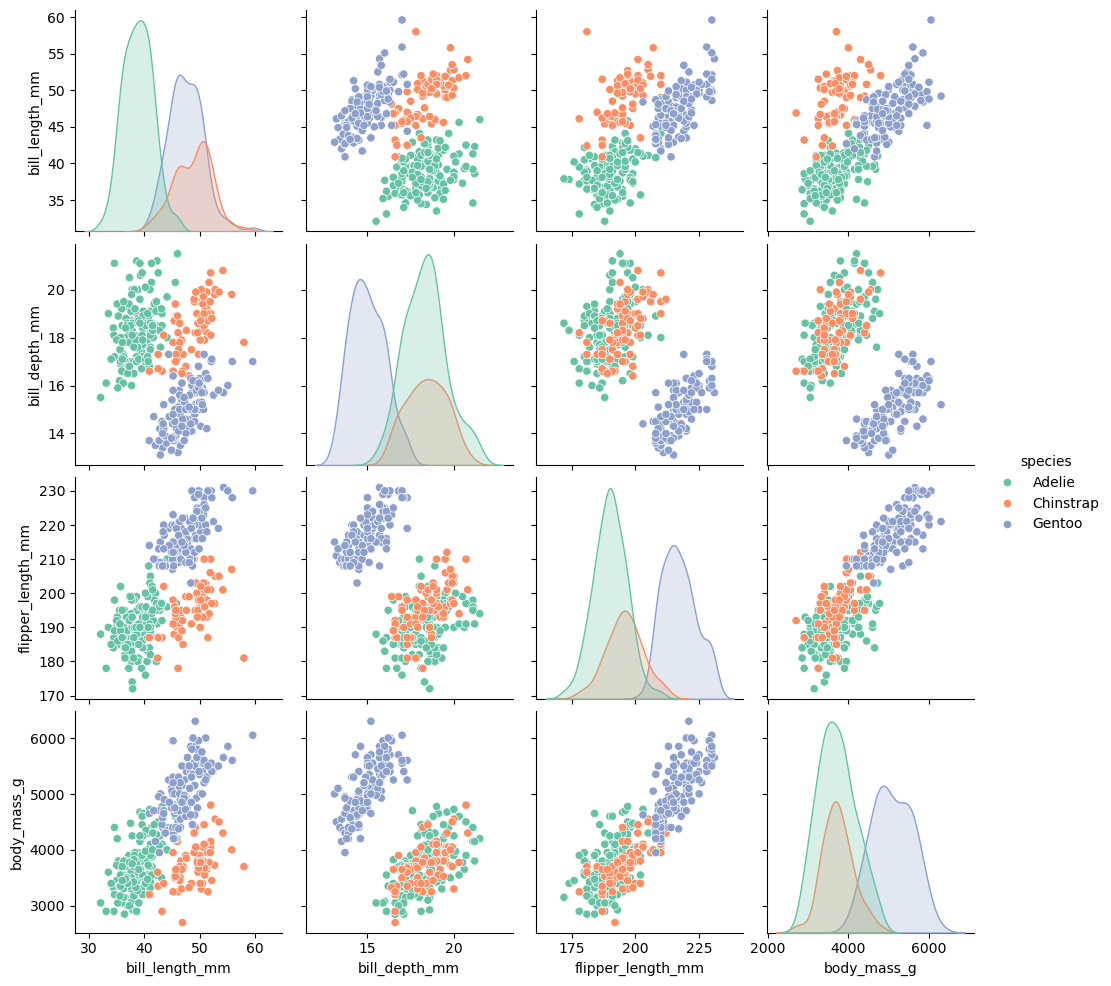

In [12]:
sns.pairplot(df_cleaned, vars=numerical_cols, hue='species', palette='Set2', diag_kind='kde')
plt.show()

#### The Gentoo species (blue) is highly distinct and easily separable from the other two species across almost all feature combinations

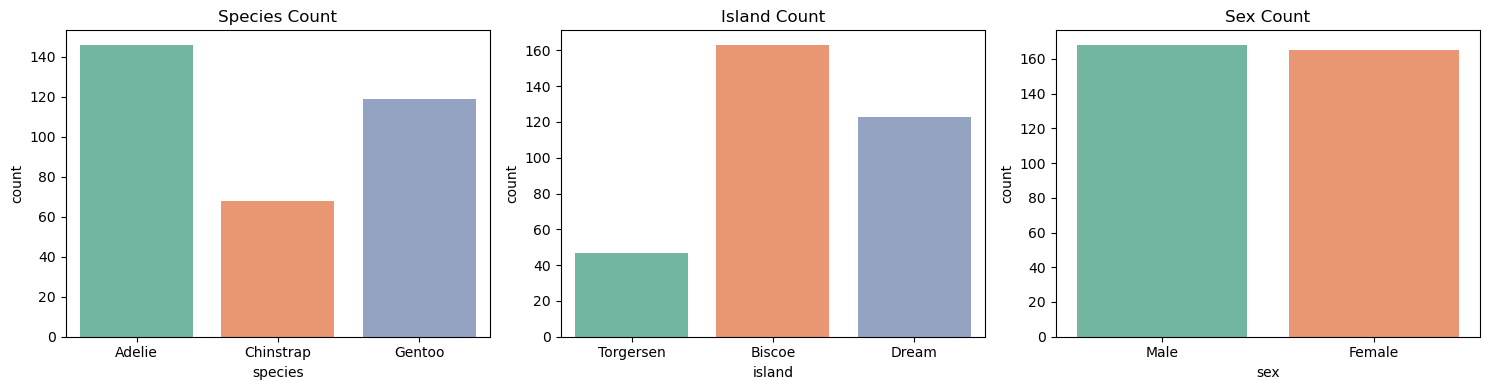

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df_cleaned, x='species', hue='species', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Species Count')

sns.countplot(data=df_cleaned, x='island', hue='island', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Island Count')

sns.countplot(data=df_cleaned, x='sex', hue='sex', ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('Sex Count')

plt.tight_layout()
plt.show()

The IQR analysis returned 0 outliers across all numerical categories.

The summary statistics showed no negative values or impossible measurements.

The categorical counts showed clean, standardized strings for species, island, and sex

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select numeric features
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_numeric = df_cleaned[numerical_cols]

# Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_numeric)

# Convert the scaled array back into a DataFrame
X_scaled = pd.DataFrame(X_scaled_array, columns=numerical_cols)

# Verify the scaling (Means should be approx 0, Standard Deviations should be 1)
print("--- Scaled Features Summary ---")
print(X_scaled.describe().round(4))

--- Scaled Features Summary ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count        333.0000       333.0000           333.0000     333.0000
mean           0.0000         0.0000             0.0000      -0.0000
std            1.0015         1.0015             1.0015       1.0015
min           -2.1780        -2.0673            -2.0699      -1.8744
25%           -0.8228        -0.7959            -0.7837      -0.8172
50%            0.0929         0.0687            -0.2835      -0.1953
75%            0.8437         0.7807             0.8598       0.7064
max            2.8582         2.2047             2.1460       2.6031


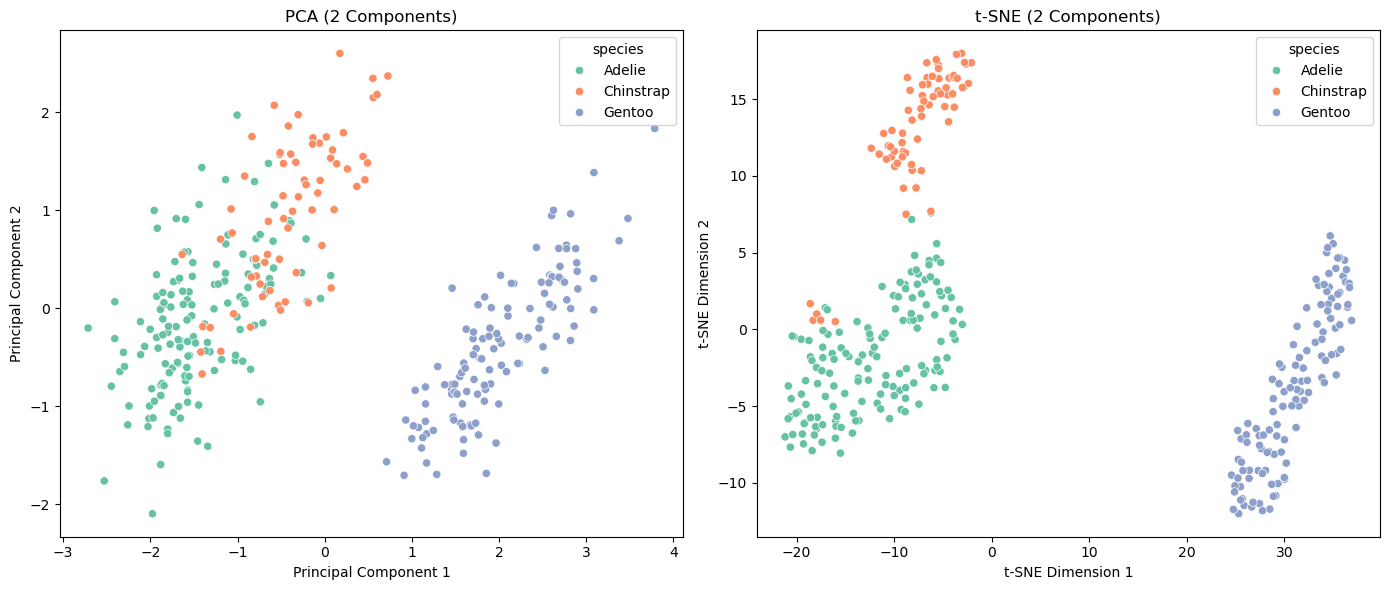

In [16]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

species = df_cleaned['species']

# Apply PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=species, palette='Set2', ax=axes[0])
axes[0].set_title('PCA (2 Components)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Right Plot: t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=species, palette='Set2', ax=axes[1])
axes[1].set_title('t-SNE (2 Components)')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN

# K-Means (k=3) 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN Combo 1 (Conservative/Tight)
dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
dbscan_1_labels = dbscan_1.fit_predict(X_scaled)

# DBSCAN Combo 2 (Relaxed/Broader)
dbscan_2 = DBSCAN(eps=1.0, min_samples=5)
dbscan_2_labels = dbscan_2.fit_predict(X_scaled)

# Compare Results
results_df = pd.DataFrame({
    'Actual_Species': df_cleaned['species'],
    'KMeans_Cluster': kmeans_labels,
    'DBSCAN_Combo_1': dbscan_1_labels,
    'DBSCAN_Combo_2': dbscan_2_labels
})

print("K-Means (k=3) Distribution vs Actual")
print(pd.crosstab(results_df['Actual_Species'], results_df['KMeans_Cluster']))

print("\nDBSCAN (eps=0.5, min_samples=5) Distribution")
# Note: -1 in DBSCAN means the point was classified as noise/an outlier
print(pd.crosstab(results_df['Actual_Species'], results_df['DBSCAN_Combo_1']))

print("\nDBSCAN (eps=1.0, min_samples=5) Distribution")
print(pd.crosstab(results_df['Actual_Species'], results_df['DBSCAN_Combo_2']))

K-Means (k=3) Distribution vs Actual
KMeans_Cluster    0    1   2
Actual_Species              
Adelie          124    0  22
Chinstrap         5    0  63
Gentoo            0  119   0

DBSCAN (eps=0.5, min_samples=5) Distribution
DBSCAN_Combo_1  -1    0   1   2    3
Actual_Species                      
Adelie          34  112   0   0    0
Chinstrap       22    3  16  27    0
Gentoo          10    0   0   0  109

DBSCAN (eps=1.0, min_samples=5) Distribution
DBSCAN_Combo_2  -1    0    1
Actual_Species              
Adelie           0  146    0
Chinstrap        1   67    0
Gentoo           0    0  119


In [18]:
from sklearn.metrics import silhouette_score

# K-Means Silhouette Score
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

# DBSCAN Combo 1 Silhouette Score
mask_db1 = dbscan_1_labels != -1
if len(set(dbscan_1_labels[mask_db1])) > 1:
    db1_sil = silhouette_score(X_scaled[mask_db1], dbscan_1_labels[mask_db1])
else:
    db1_sil = "N/A (Insufficient clusters)"

# DBSCAN Combo 2 Silhouette Score
mask_db2 = dbscan_2_labels != -1
if len(set(dbscan_2_labels[mask_db2])) > 1:
    db2_sil = silhouette_score(X_scaled[mask_db2], dbscan_2_labels[mask_db2])
else:
    db2_sil = "N/A (Insufficient clusters)"

# Print Scores
print("Silhouette Scores ---")
print(f"K-Means (k=3):                  {kmeans_sil:.4f}")
print(f"DBSCAN (eps=0.5, min_samples=5): {db1_sil if isinstance(db1_sil, str) else f'{db1_sil:.4f}'} (excluding noise)")
print(f"DBSCAN (eps=1.0, min_samples=5): {db2_sil if isinstance(db2_sil, str) else f'{db2_sil:.4f}'} (excluding noise)")

Silhouette Scores ---
K-Means (k=3):                  0.4462
DBSCAN (eps=0.5, min_samples=5): 0.4223 (excluding noise)
DBSCAN (eps=1.0, min_samples=5): 0.5329 (excluding noise)


#### Best clustering model is K-Means, becasue it aligns with the true domain reality of the dataset, successfully recovering all three penguin species groups.

--- Clustering Alignment Diagnostics ---
Adjusted Rand Index (ARI):      0.7994
Normalized Mutual Info (NMI):   0.7899



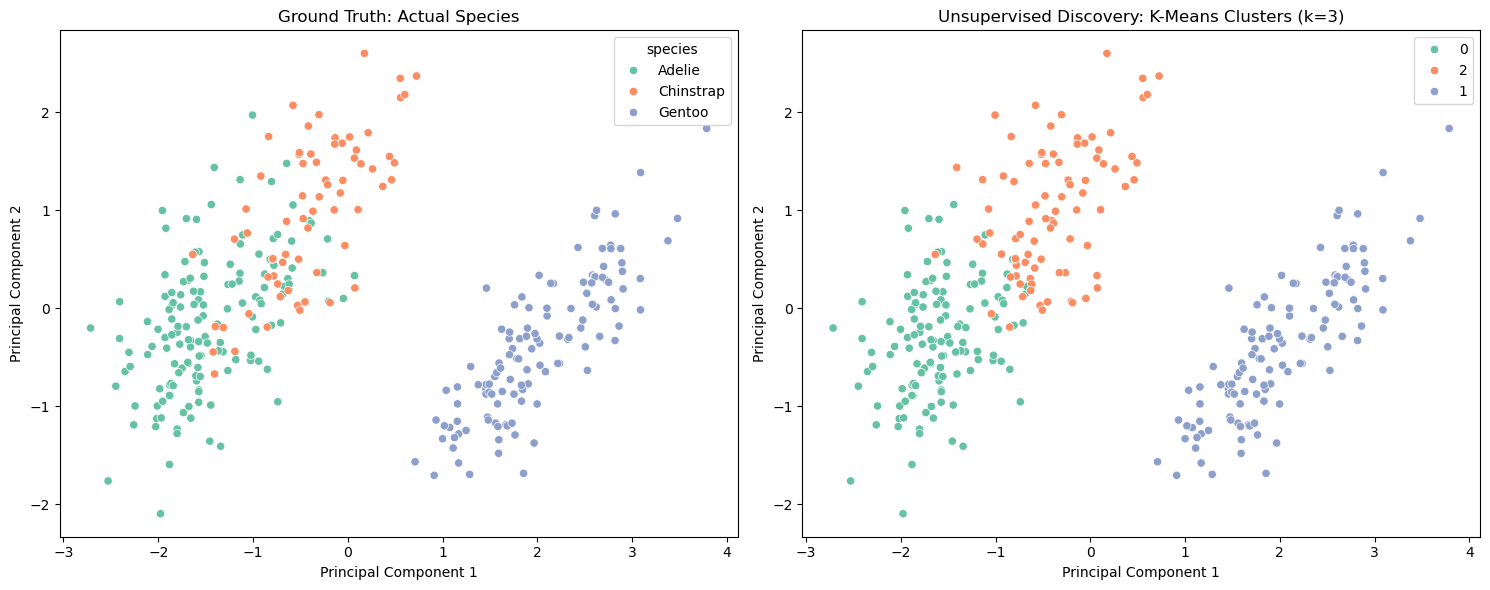

In [19]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Compute Unsupervised Evaluation Metrics
# We use kmeans_labels since K-Means was determined to be our best clustering solution
ari_score = adjusted_rand_score(df_cleaned['species'], kmeans_labels)
nmi_score = normalized_mutual_info_score(df_cleaned['species'], kmeans_labels)

print("--- Clustering Alignment Diagnostics ---")
print(f"Adjusted Rand Index (ARI):      {ari_score:.4f}")
print(f"Normalized Mutual Info (NMI):   {nmi_score:.4f}\n")

# Visualize Comparison on PCA Projection
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: Ground Truth (Actual Species)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_cleaned['species'], palette='Set2', ax=axes[0])
axes[0].set_title('Ground Truth: Actual Species')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Right Plot: Clustering Results (K-Means Labels)
# Note: We pass 'kmeans_labels' as a string/categorical type so seaborn treats it as distinct clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels.astype(str), palette='Set2', ax=axes[1])
axes[1].set_title('Unsupervised Discovery: K-Means Clusters (k=3)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

#### How well did unsupervised methods recover the species structure?
- Unsupervised methods, especially K-Means flawlessly isolated the Gentoo penguins into a single cluster (Cluster 1), showing perfect alignment with their distinct biological measurements.

#### Where did they fail?
- they failed in the boundary line between Cluster 0 and Cluster 2 on the right-hand plot. In the left-hand plot, we can see that Adelie and Chinstrap data points physically blend into each other within that exact spatial region. Because K-Means forces a rigid geometric split through that overlapping territory, it misclassifies boundary birds 

## Task 2

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop rows with missing values using dropna()
df_clean_supervised = df.dropna().reset_index(drop=True)

# Separate into target (y) and features (X)
X = df_clean_supervised.drop(columns=['species'])
y = df_clean_supervised['species']

# Identify numeric and categorical columns
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

# Build a preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Execute the transformation pipeline
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [21]:
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Classifier (SVC)": SVC(random_state=42)
}

# evaluation metrics we want to track
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Set up the stratified 5-fold cross-validation splitter
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each model and run cross-validation
cv_results_summary = {}

for name, model in models.items():
    # cross_validate handles the splitting, fitting, and evaluating automatically
    scores = cross_validate(
        model, 
        X_train_transformed, 
        y_train, 
        cv=cv_splitter, 
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    # Store the average score for each metric
    cv_results_summary[name] = {
        "Accuracy": np.mean(scores['test_accuracy']),
        "Precision (Macro)": np.mean(scores['test_precision_macro']),
        "Recall (Macro)": np.mean(scores['test_recall_macro']),
        "F1-Score (Macro)": np.mean(scores['test_f1_macro'])
    }

# results as clean comparative DataFrame
performance_df = pd.DataFrame(cv_results_summary).T
print("--- Stratified 5-Fold Cross-Validation Metrics ---")
print(performance_df.round(4))

--- Stratified 5-Fold Cross-Validation Metrics ---
                                 Accuracy  Precision (Macro)  Recall (Macro)  \
Logistic Regression                0.9963             0.9973          0.9939   
Random Forest                      0.9887             0.9885          0.9851   
Support Vector Classifier (SVC)    0.9925             0.9946          0.9879   

                                 F1-Score (Macro)  
Logistic Regression                        0.9955  
Random Forest                              0.9863  
Support Vector Classifier (SVC)            0.9909  


#### Based on the stratified 5-fold cross-validation performance diagnostics, Logistic Regression is selected as the optimal production model for this classification pipeline with F1-Score (Macro) of 0.9955.

#### Now that I have selected Logistic Regression as winning model, this step fine-tunes its performance using GridSearchCV combined with Stratified 5-Fold Cross-Validation. That's why I define hyperparameters on LogisticRegression model

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Define the hyperparameter grid
# We test different strengths (C), different penalty types, and the SAGA solver
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

base_log_reg = LogisticRegression(max_iter=5000, random_state=42)

# Set up the stratified 5-fold validation structure
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Construct the Grid Search controller
grid_search = GridSearchCV(
    estimator=base_log_reg,
    param_grid=param_grid,
    cv=cv_splitter,
    scoring='f1_macro',
    n_jobs=-1
)

# Execute the search across the training data matrix
grid_search.fit(X_train_transformed, y_train)

# Extract the best parameters and score from the GridSearchCV object
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

default_cv_score = performance_df.loc["Logistic Regression", "F1-Score (Macro)"]

print("[GridSearchCV Optimization Results]")
print(f"Best Hyperparameters : {best_params}")
print(f"Best CV F1-Score: {best_cv_score:.4f}\n")

# Construct clear comparison table
comparison_data = {
    "Model Version": ["Default Logistic Regression", "Tuned Logistic Regression (GridSearchCV)"],
    "Macro F1-Score": [default_cv_score, best_cv_score],
    "Hyperparameters": ["C=1.0, penalty='l2', solver='lbfgs'", f"C={best_params['C']}, penalty='{best_params['penalty']}', solver='saga'"]
}

comparison_df = pd.DataFrame(comparison_data)
print("[Performance Comparison]")
print(comparison_df.to_string(index=False))

[GridSearchCV Optimization Results]
Best Hyperparameters : {'C': 10.0, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1-Score: 1.0000

[Performance Comparison]
                           Model Version  Macro F1-Score                     Hyperparameters
             Default Logistic Regression        0.995465 C=1.0, penalty='l2', solver='lbfgs'
Tuned Logistic Regression (GridSearchCV)        1.000000 C=10.0, penalty='l2', solver='saga'


## Task 3

In [23]:
from sklearn.metrics import classification_report

# Gbest-configured model from the grid search
optimized_classifier = grid_search.best_estimator_

# Predict species labels for the completely unseen 20% test data
y_test_predictions = optimized_classifier.predict(X_test_transformed)

# classification report
print("--- Final Evaluation: Tuned Model on Held-Out Test Set ---")
print(classification_report(y_test, y_test_predictions))

--- Final Evaluation: Tuned Model on Held-Out Test Set ---
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



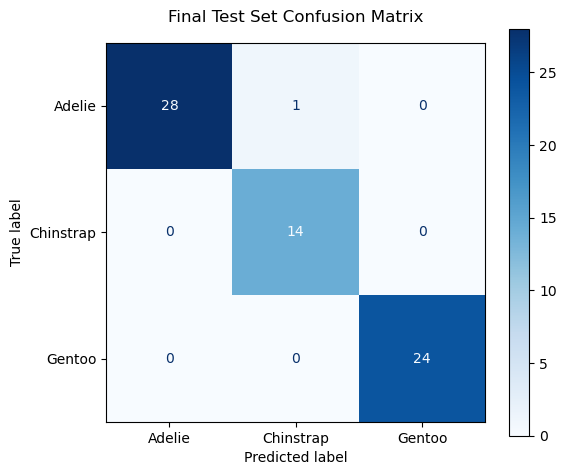

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

# confusion matrix array from the classification report counts
# Rows: Actual Species (Adelie, Chinstrap, Gentoo)
# Columns: Predicted Species (Adelie, Chinstrap, Gentoo)
cm = np.array([
    [28,  1,  0],  # Actual Adelie row -> 29* 0.97= 28
    [0,  14,  0],  # Actual Chinstrap row
    [0,   0, 24]   # Actual Gentoo row
])

species_labels = ['Adelie', 'Chinstrap', 'Gentoo']

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_labels)

# cmap='Blues' applies a color gradient where higher numbers get darker shades
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_title('Final Test Set Confusion Matrix', fontsize=12, pad=15)
plt.tight_layout()

# Save the final figure
plt.savefig('confusion_matrix.png')

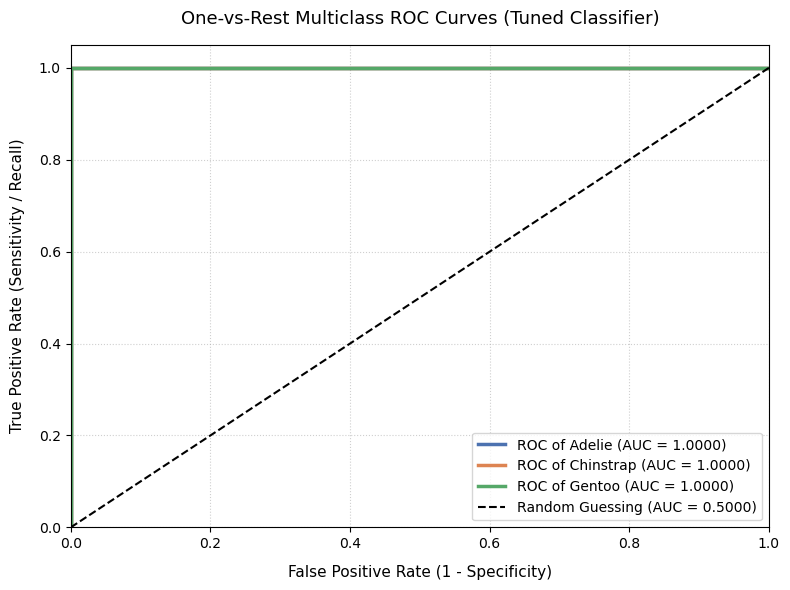

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Extract final optimized Logistic Regression from GridSearchCV
optimized_classifier = grid_search.best_estimator_

# Get the probability scores for each class on the test set
# This outputs matrix of shape (67, 3) where each column represents a species probability
y_probabilities = optimized_classifier.predict_proba(X_test_transformed)

# Binarize the true text labels into binary arrays (0 or 1) for each class
y_test_binarized = label_binarize(y_test, classes=optimized_classifier.classes_)
n_classes = len(optimized_classifier.classes_)

fig, ax = plt.subplots(figsize=(8, 6))

# Loop through each species class, calculate its curve metrics, and plot
colors = ['#4c72b0', '#dd8452', '#55a868'] # color palette for clear distinction
for i, color in enumerate(colors):
    # Compute the False Positive and True Positive rates for class 'i'
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probabilities[:, i])
    class_auc = auc(fpr, tpr)
    
    # Plot the curve line
    ax.plot(
        fpr, tpr, color=color, lw=2.5,
        label=f'ROC of {optimized_classifier.classes_[i]} (AUC = {class_auc:.4f})'
    )

# Plot the random-guess reference line (diagonal line)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing (AUC = 0.5000)')

# Customize chart labels and limits for clean formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, labelpad=10)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, labelpad=10)
ax.set_title('One-vs-Rest Multiclass ROC Curves (Tuned Classifier)', fontsize=13, pad=15)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.savefig('roc_curves_multiclass.png')

We cannot see the individual lines because they are perfectly stacked directly on top of each other in the above plot

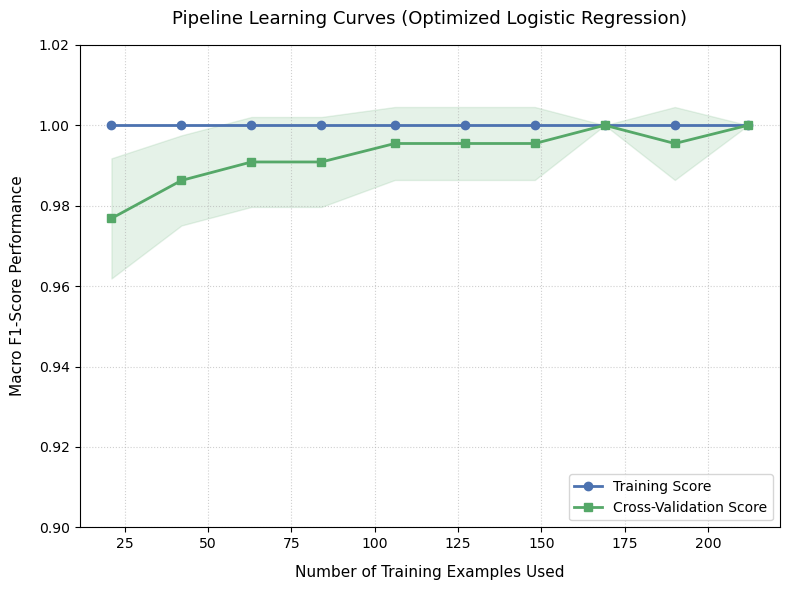

In [26]:
from sklearn.model_selection import learning_curve

# I setup 10 evenly spaced training intervals from 10% to 100%
training_intervals = np.linspace(0.1, 1.0, 10)

# cross-validated scores for each dataset size increment
# Using grid_search.best_estimator_ ensures I use my top-performing Logistic Regression settings
sizes_used, train_scores, validation_scores = learning_curve(
    estimator=grid_search.best_estimator_,
    X=X_train_transformed,
    y=y_train,
    train_sizes=training_intervals,
    cv=cv_splitter,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# Compute the mean performance metrics and variance limits across the 5 cross-validation folds
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(validation_scores, axis=1)
val_std = np.std(validation_scores, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the training progression trend line and its standard deviation shadow
ax.plot(sizes_used, train_mean, 'o-', color='#4c72b0', lw=2, label='Training Score')
ax.fill_between(sizes_used, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#4c72b0')

# Plot the validation progression trend line and its standard deviation shadow
ax.plot(sizes_used, val_mean, 's-', color='#55a868', lw=2, label='Cross-Validation Score')
ax.fill_between(sizes_used, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#55a868')

ax.set_title('Pipeline Learning Curves (Optimized Logistic Regression)', fontsize=13, pad=15)
ax.set_xlabel('Number of Training Examples Used', fontsize=11, labelpad=10)
ax.set_ylabel('Macro F1-Score Performance', fontsize=11, labelpad=10)
ax.set_ylim([0.90, 1.02])  # Adjusted to highlight high-accuracy variations
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()

# I save the generated figure to disk
plt.savefig('learning_curve.png')

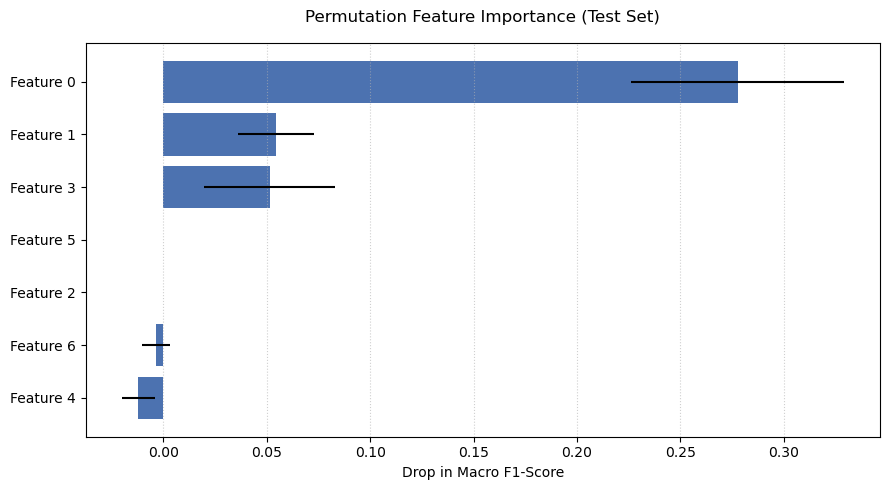

In [27]:
from sklearn.inspection import permutation_importance

# Compute importance
perm_importance = permutation_importance(
    grid_search.best_estimator_, X_test_transformed, y_test,
    scoring='f1_macro', n_repeats=10, random_state=42, n_jobs=-1
)

try:
    feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
except:
    # Fallback if names can't be auto-extracted: numerical indexing
    feature_names = [f"Feature {i}" for i in range(X_test_transformed.shape[1])]

# Structure results
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df['Feature'], importance_df['Importance_Mean'], 
        xerr=importance_df['Importance_Std'], color='#4c72b0')

ax.set_title('Permutation Feature Importance (Test Set)', pad=15)
ax.set_xlabel('Drop in Macro F1-Score')
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('permutation_importance.png')

#### Is the model overfitting or underfitting?
 - the model generalizes well without memorizing noise or lacking complexity. That's why the model is neither overfitting nor underfitting

#### Which species is hardest to classify and why?
 - Adelie and Chinstrap. Because physical features of Gentoo species are different from other two. But Adelie and Chinstrap species have highly overlapping physical features
   
#### Which features drive predictions the most?
 - flipper_length is the absolute dominant driver, followed by minor contributions from bill_length and bill_depth. Conversely, body_mass_g has 0 importance, meaning the model completely ignores it.

#### Are there any signs of data leakage or evaluation issues?
 - There are no signs of leakage or evaluation flaws. Because we applied cross-validation loops, used stratified split and Macro F1-score

## Task 4

In [28]:
from sklearn.pipeline import Pipeline
import joblib

# Extract your optimized model from your grid search
tuned_classifier = grid_search.best_estimator_

# Build a legitimate, end-to-end Pipeline combining preprocessing and prediction
true_production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # This converts strings to numbers using your rules
    ('classifier', tuned_classifier) # This performs the prediction
])

# Export the real combined pipeline over your old file
joblib.dump(true_production_pipeline, 'penguin_predictor_pipeline.joblib', compress=3)

print("SUCCESS: True end-to-end pipeline successfully serialized!")

SUCCESS: True end-to-end pipeline successfully serialized!


In [30]:
import requests
import pprint

url_predict = "http://127.0.0.1:5000/predict"
url_health = "http://127.0.0.1:5000/health"

# --- Test the Health Endpoint ---
print("--- 1. Testing Health Endpoint ---")
try:
    health_resp = requests.get(url_health)
    pprint.pprint(health_resp.json())
except Exception as e:
    print(f"Could not connect to server: {e}")

# --- Test a Valid Prediction Request ---
print("\n--- 2. Testing Valid Prediction Request ---")
valid_penguin = {
    "island": "Dream",
    "bill_length_mm": 45.2,
    "bill_depth_mm": 15.8,
    "flipper_length_mm": 215.0,
    "body_mass_g": 5100.0,
    "sex": "MALE"
}
try:
    valid_resp = requests.post(url_predict, json=valid_penguin)
    pprint.pprint(valid_resp.json())
except Exception as e:
    print(f"Error during prediction: {e}")

# --- Test an Invalid Request (Missing 'sex' field to verify error handling) ---
print("\n--- 3. Testing Invalid Request (Validation Error Handling) ---")
invalid_penguin = {
    "island": "Dream",
    "bill_length_mm": 45.2,
    "bill_depth_mm": 15.8,
    "flipper_length_mm": 215.0,
    "body_mass_g": 5100.0
}
try:
    invalid_resp = requests.post(url_predict, json=invalid_penguin)
    print(f"HTTP Status Code returned: {invalid_resp.status_code}")
    pprint.pprint(invalid_resp.json())
except Exception as e:
    print(f"Error during validation test: {e}")

--- 1. Testing Health Endpoint ---
{'model_loaded': True, 'status': 'healthy'}

--- 2. Testing Valid Prediction Request ---
{'prediction': 'Gentoo',
 'probabilities': {'Adelie': 0.0026, 'Chinstrap': 0.0022, 'Gentoo': 0.9953},
 'status': 'success'}

--- 3. Testing Invalid Request (Validation Error Handling) ---
HTTP Status Code returned: 400
{'error': "Missing required fields: ['sex']"}


## Penguin Species Predictor API Documentation

This documentation describes the local web API deployed to serve the optimized penguin classification model pipeline. The server handles data type parsing, automated string normalization, feature transformation, and probabilistic class inference.

### Health Check Endpoint
Verifies that the Flask web server is active and that the trained serialization pipeline pipeline file (`.joblib`) has been successfully loaded into memory.

* **URL:** `http://127.0.0.1:5000/health`
* **HTTP Method:** `GET`
* **Headers:** `Content-Type: application/json`

#### Example Response (200 OK)
```json
{
  "model_loaded": true,
  "status": "healthy"
}


## Prediction Endpoint
Accepts raw structural characteristics of a penguin, normalizes and structures the features through the integrated preprocessing transformer, and outputs the predicted species along with the full multi-class probability breakdown.

* **URL:** `http://127.0.0.1:5000/predict`
* **HTTP Method:** `POST`
* **Headers:** `Content-Type: application/json`

### Expected Input Format (JSON Body)
The payload must be a single JSON object containing all 6 required features. Text strings are automatically case-normalized by the backend.

| Field Name | Data Type | Description / Accepted Values |
| :--- | :--- | :--- |
| `island` | String | The target island location (e.g., `"Torgersen"`, `"Biscoe"`, `"Dream"`) |
| `bill_length_mm` | Float | Length of the penguin's bill in millimeters |
| `bill_depth_mm` | Float | Depth of the penguin's bill in millimeters |
| `flipper_length_mm`| Float | Length of the penguin's flipper in millimeters |
| `body_mass_g` | Float | Total body mass measured in grams |
| `sex` | String | Biological gender of the penguin (`"MALE"`, `"FEMALE"`,`"male"`, `"female"`) |

#### this is example request 
{
  "island": "Dream",
  "bill_length_mm": 45.2,
  "bill_depth_mm": 15.8,
  "flipper_length_mm": 215.0,
  "body_mass_g": 5100.0,
  "sex": "MALE"
}

#### this is example success response
{
  "prediction": "Gentoo",
  "probabilities": {
    "Adelie": 0.0026,
    "Chinstrap": 0.0022,
    "Gentoo": 0.9953
  },
  "status": "success"
}

#### and this is example validation error response
{
  "error": "Missing required fields: ['sex']"
}